In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sol_numerica_erro_contorno(m, p):
    # Resolve $u'' = -\pi^2\sin(\pi x)$ com diferenças finitas com erro $h^p$ em $x=0$

    h = 1 / (m+1)
    x = np.linspace(h, 1-h, m)

    ### Monta a matriz $A$ e o vetor $\vec{f}$
    A = (np.diag(np.ones(m-1), k=-1) - 2*np.diag(np.ones(m)) + np.diag(np.ones(m-1), k=1)) / h**2
    f_vec = -np.pi**2 * np.sin(np.pi*x)
    f_vec[0] += h**(p-2)

    ### Resolve o sistema com o numpy (decomposição LU com pivotamento parcial)
    u_h_vec = np.linalg.solve(A, f_vec)

    return u_h_vec

def norma_do_erro(q, u_h_vec):
    # Calcula a $q$-norma do erro

    m = len(u_h_vec)
    h = 1 / (m+1)
    x = np.linspace(h, 1-h, m)
    erro_vec = u_h_vec - np.sin(np.pi*x)

    ### Se for a $\infty$-norma então retorna o máximo dos erros ponto a ponto
    if q == 'inf':
        return np.max(np.abs(erro_vec))

    return (h * np.sum(np.abs(erro_vec)**q))**(1/q)

In [2]:
### Valores de $m$, $p$ que queremos varrer
pontos_internos = [2**3, 2**4, 2**5, 2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12]
ordens_erros = [-1, 0, 1, 2, 3]

### Lista para armazenar os resultados
normas_p = []

### Faz os estudos de convergência e armazena em normas_p
for p in ordens_erros:
    normas = []
    for m in pontos_internos:
        solucao = sol_numerica_erro_contorno(m, p)
        normas.append(norma_do_erro('inf', solucao))
    normas_p.append(normas)

In [3]:
### Monta a tabela organizada da análise de convergência com os erros $\mathcal{O}(h^p)$ na borda
print('-'*60)
print(f' {'m':^4} | {'p=-1':^8}   {'p=0':^8}   {'p=1':^8}   {'p=2':^8}   {'p=3':^8}')
print('-'*60)
for i in range(len(pontos_internos)):
    if i==0:
        print(f' {pontos_internos[i]:<4} | {'-':^8}   {'-':^8}   {'-':^8}   {'-':^8}   {'-':^8}')
        continue
    ### Calcula a estimativa das ordens usando $p \approx \log_2[E_q(h)/E_q(h/2)]$
    p_neg = np.log2(normas_p[0][i-1]/normas_p[0][i])
    p_0 = np.log2(normas_p[1][i-1]/normas_p[1][i])
    p_1 = np.log2(normas_p[2][i-1]/normas_p[2][i])
    p_2 = np.log2(normas_p[3][i-1]/normas_p[3][i])
    p_3 = np.log2(normas_p[4][i-1]/normas_p[4][i])
    print(f' {pontos_internos[i]:<4} | {p_neg:^8.4f}   {p_0:^8.4f}   {p_1:^8.4f}   {p_2:^8.4f}   {p_3:^8.4f}')
print('-'*60)

------------------------------------------------------------
  m   |   p=-1       p=0        p=1        p=2        p=3   
------------------------------------------------------------
 8    |    -          -          -          -          -    
 16   | -1.0006    -0.0873     0.7968     1.4526     1.7848 
 32   | -1.0000    -0.0438     0.9037     1.7391     1.8876 
 64   | -1.0000    -0.0221     0.9533     1.8720     1.9425 
 128  | -1.0000    -0.0112     0.9770     1.9366     1.9709 
 256  | -1.0000    -0.0056     0.9886     1.9684     1.9854 
 512  | -1.0000    -0.0028     0.9943     1.9842     1.9927 
 1024 | -1.0000    -0.0014     0.9972     1.9921     1.9963 
 2048 | -1.0000    -0.0007     0.9986     1.9961     1.9982 
 4096 | -1.0000    -0.0004     0.9993     1.9980     1.9991 
------------------------------------------------------------


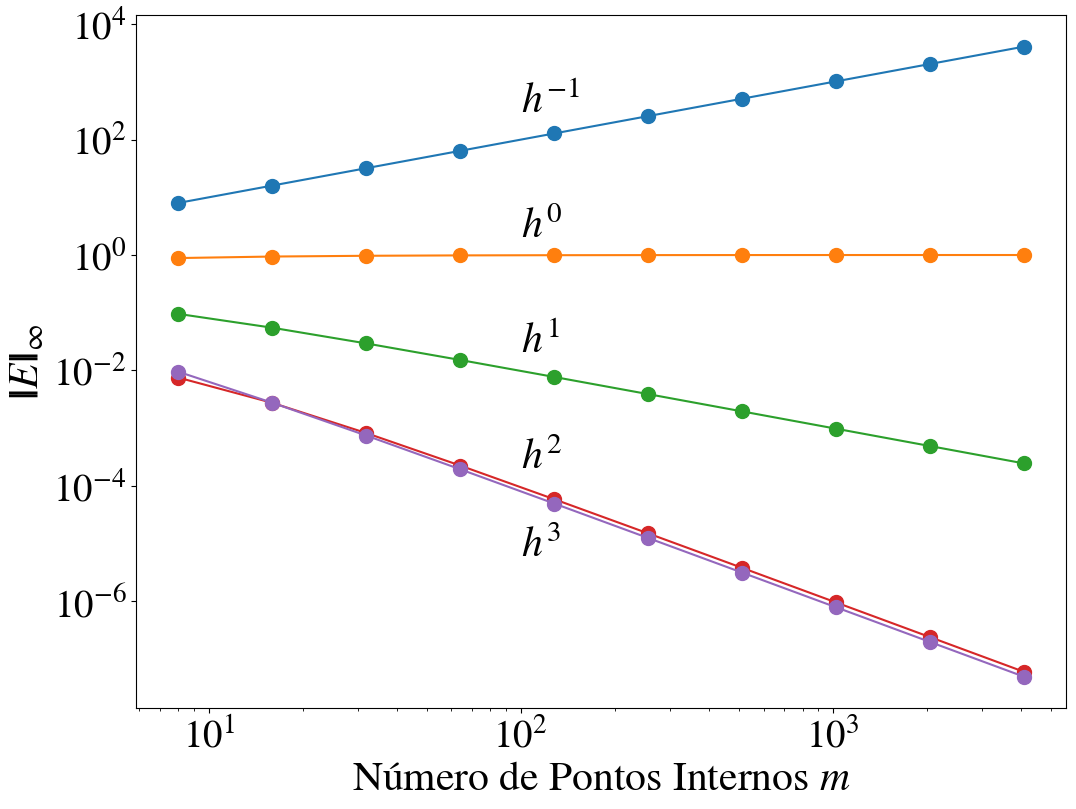

In [4]:
### Plota o gráfico de convergência de erros de ordem $p$ diferentes em função de $m$
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

fig, ax = plt.subplots(figsize=(12,9))

for p in range(len(ordens_erros)):
    ax.loglog(pontos_internos, normas_p[p], 'o-', label=f'$p={ordens_erros[p]}$', ms=10)

ax.text(1e2, 3e2, r'$h^{-1}$', fontsize=30)
ax.text(1e2, 2e0, r'$h^{0}$', fontsize=30)
ax.text(1e2, 2e-2, r'$h^{1}$', fontsize=30)
ax.text(1e2, 2e-4, r'$h^{2}$', fontsize=30)
ax.text(1e2, 6e-6, r'$h^{3}$', fontsize=30)

ax.tick_params(axis='both', which='major', labelsize=28)
ax.set_xlabel(r'Número de Pontos Internos $m$', fontsize=30)
ax.set_ylabel(r'$|\!|E|\!|_\infty$', fontsize=30)
plt.savefig('erro_contorno.svg')
plt.show()